Found 878 images belonging to 3 classes.
Found 219 images belonging to 3 classes.


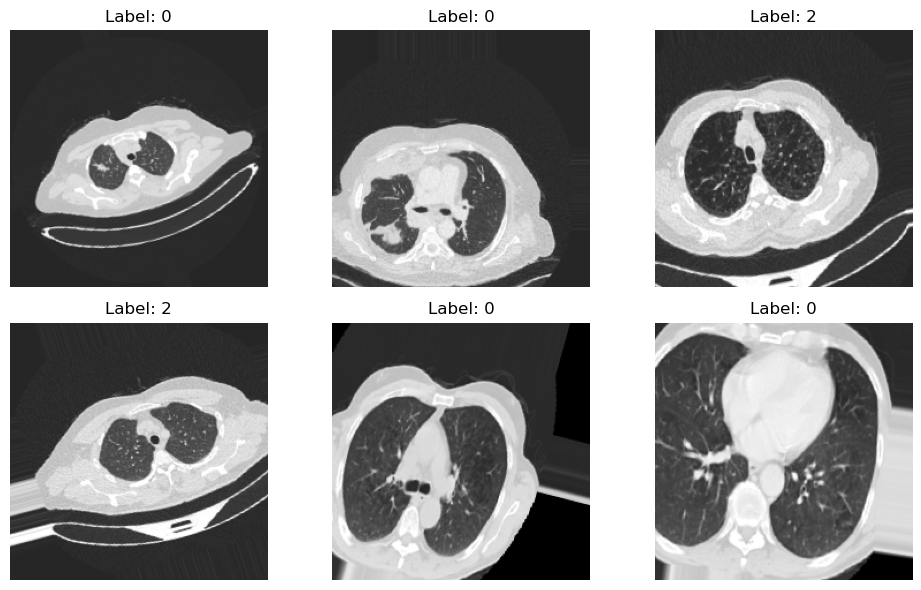

C:\Users\jaint\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 167s 3s/step - accuracy: 0.5101 - loss: 1.1233 - val_accuracy: 0.6712 - val_loss: 0.7971
Epoch 2/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 154s 3s/step - accuracy: 0.7096 - loss: 0.7263 - val_accuracy: 0.7489 - val_loss: 0.7384
Epoch 3/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 229s 4s/step - accuracy: 0.7616 - loss: 0.5692 - val_accuracy: 0.6575 - val_loss: 0.8143
Epoch 4/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 250s 5s/step - accuracy: 0.8249 - loss: 0.5035 - val_accuracy: 0.7306 - val_loss: 0.7261
Epoch 5/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 263s 5s/step - accuracy: 0.8293 - loss: 0.4636 - val_accuracy: 0.7626 - val_loss: 0.7000
Epoch 6/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 240s 4s/step - accuracy: 0.8464 - loss: 0.4041 - val_accuracy: 0.7717 - val_loss: 0.7381
Epoch 7/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 233s 4s/step - accuracy: 0.8423 - loss: 0.4089 - val_accuracy: 0.7808 - val_loss: 0.6893
Epoch 8/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 208s 4s/step - accuracy: 0.8460 - loss: 0.3604 - val_accuracy: 0.7215 - v

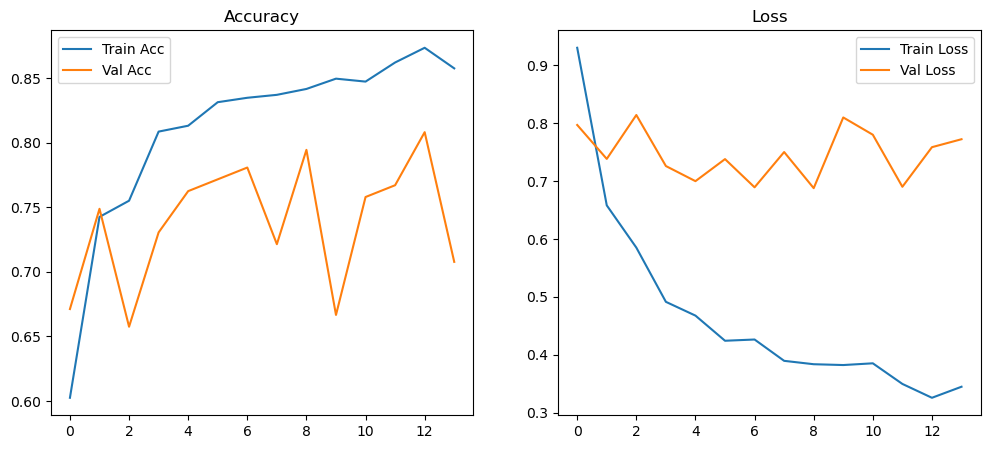

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step


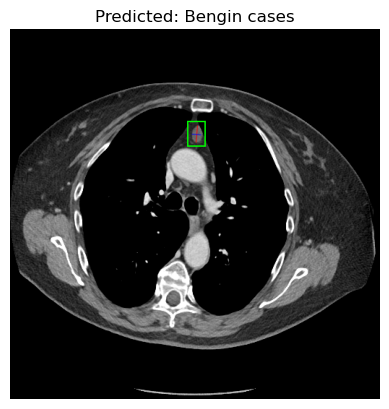

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step


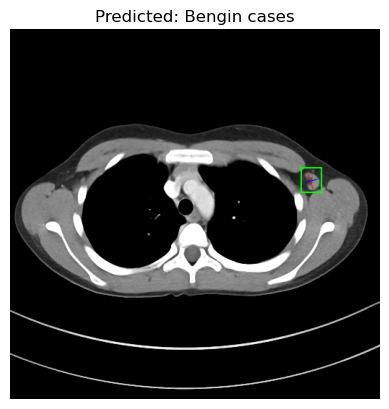

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step


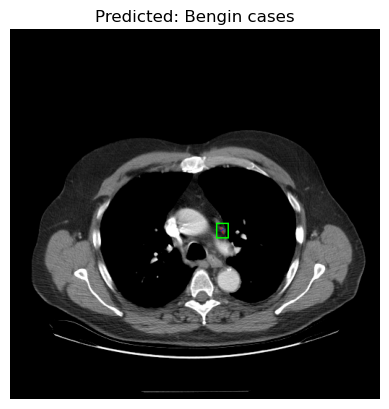

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step


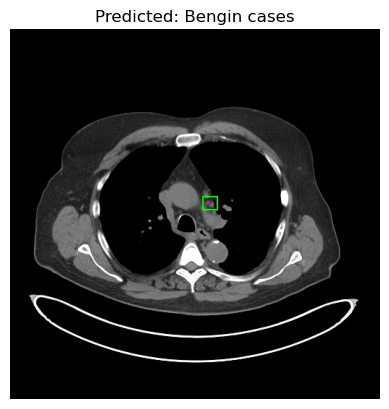

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step


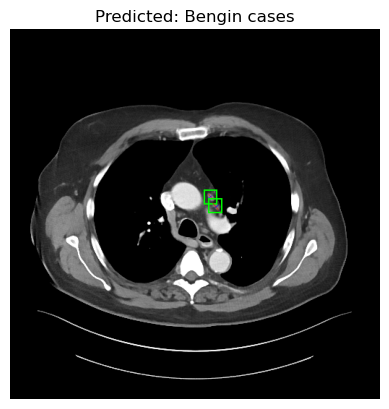

Class indices: {'Bengin cases': 0, 'Malignant cases': 1, 'Normal cases': 2}
✅ Model saved successfully in new format!


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import load_img, img_to_array
import glob

# ==============================
# 1️⃣ Dataset Paths (✅ Corrected)
# ==============================
train_dir = r"..\data\lung_cancer\The IQ-OTHNCCD lung cancer dataset\The IQ-OTHNCCD lung cancer dataset"
test_dir = r"..\data\lung_cancer\Test cases"

# ==============================
# 2️⃣ Data Preprocessing
# ==============================
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='validation'
)

# ==============================
# 3️⃣ Visualize Few Images
# ==============================
x_batch, y_batch = next(iter(train_gen))

plt.figure(figsize=(10, 6))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(x_batch[i])
    plt.title(f"Label: {np.argmax(y_batch[i])}")
    plt.axis("off")
plt.tight_layout()
plt.show()

# ==============================
# 4️⃣ Model: Transfer Learning (VGG16)
# ==============================
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # freeze base model

model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')  # 3 classes: Normal, Benign, Malignant
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ==============================
# 5️⃣ Training
# ==============================
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=[early_stop]
)

# ==============================
# 6️⃣ Model Evaluation
# ==============================
val_loss, val_acc = model.evaluate(val_gen)
print(f"✅ Validation Accuracy: {val_acc:.2f}")
print(f"✅ Validation Loss: {val_loss:.2f}")

# ==============================
# 7️⃣ Plot Accuracy and Loss
# ==============================
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')
plt.show()

# ==============================
# 8️⃣ Predict on Test Images (✅ Manual)
# ==============================
test_images = glob.glob(test_dir + "/*.png") + glob.glob(test_dir + "/*.jpg")
classes = list(train_gen.class_indices.keys())

for path in test_images[:5]:  # show predictions for first 5 test images
    img = load_img(path, target_size=(224, 224))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    pred = model.predict(img_array)
    label = classes[np.argmax(pred)]

    plt.imshow(load_img(path))
    plt.title(f"Predicted: {label}")
    plt.axis('off')
    plt.show()

# ==============================
# 9️⃣ Class Mapping
# ==============================
print("Class indices:", train_gen.class_indices)

# ==============================
# 🔟 Save Model
# ==============================
model.save("../model/lung_cancer_vgg16_model.keras")
print("✅ Model saved successfully in new format!")


In [2]:
import tensorflow as tf

# Load with legacy compatibility
model = tf.keras.models.load_model(
    "model/lung_cancer_vgg16_model.keras",
    custom_objects=None,
    compile=False
)

# Resave in current format
model.save("model/lung_cancer_vgg16_model_fixed.keras")
print("Resaved successfully!")

ValueError: File not found: filepath=model/lung_cancer_vgg16_model.keras. Please ensure the file is an accessible `.keras` zip file.